# NB3 — DPO Training (the main event)

**Stack:** TRL `DPOTrainer` + `DPOConfig(beta=0.1, lr=5e-7)` from deck §5.2.
Maps to deck §3 (DPO derivation), §3.4 (failure modes — read closely!), §5.2 (TRL impl).

> **Mục tiêu:** train DPO adapter on top of NB1 SFT-mini. Plot reward curves
> (cả `chosen_rewards` và `rejected_rewards`). Save adapter to `adapters/dpo/`.
>
> Đây là **the** notebook quan trọng nhất của lab — 25/100 pts đến từ đây.
> Đặc biệt là: **plot cả 2 curve riêng biệt**, không chỉ reward gap (deck §3.4).

## 0. Setup

In [5]:
from pathlib import Path

# Create folders
Path("data/pref").mkdir(parents=True, exist_ok=True)

# Check
!ls -R data

data:
pref

data/pref:


In [6]:
from pathlib import Path

Path("/content/adapters/sft-mini").mkdir(parents=True, exist_ok=True)

# check
!ls -R /content/adapters

/content/adapters:
dpo  sft-mini

/content/adapters/dpo:

/content/adapters/sft-mini:


In [2]:
import os
from pathlib import Path

COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()

if COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-3B-bnb-4bit"
    MAX_LEN = 512
    MAX_PROMPT_LEN = 256
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
else:
    BASE_MODEL = "unsloth/Qwen2.5-7B-bnb-4bit"
    MAX_LEN = 1024
    MAX_PROMPT_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 4

# Hyperparameters from deck §5.2 (TRL DPOTrainer implementation frame)
BETA = float(os.environ.get("DPO_BETA", "0.1"))
LR = float(os.environ.get("DPO_LR", "5e-7"))
EPOCHS = int(os.environ.get("DPO_EPOCHS", "1"))

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SFT_PATH = REPO_ROOT / "adapters" / "sft-mini"
DPO_OUT = REPO_ROOT / "adapters" / "dpo"
PREF_PATH = REPO_ROOT / "data" / "pref" / "train.parquet"

DPO_OUT.mkdir(parents=True, exist_ok=True)

assert SFT_PATH.exists(), f"NB1 must run first — {SFT_PATH} missing"
assert PREF_PATH.exists(), f"NB2 must run first — {PREF_PATH} missing"

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"DPO hyperparams: beta={BETA}  lr={LR}  epochs={EPOCHS}")
print(f"max_length:      {MAX_LEN}  (prompt={MAX_PROMPT_LEN})")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"SFT input:       {SFT_PATH}")
print(f"output:          {DPO_OUT}")

COMPUTE_TIER:    T4
BASE_MODEL:      unsloth/Qwen2.5-3B-bnb-4bit
DPO hyperparams: beta=0.1  lr=5e-07  epochs=1
max_length:      512  (prompt=256)
effective batch: 8
SFT input:       /content/adapters/sft-mini
output:          /content/adapters/dpo


In [3]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."

In [ ]:
!pip install unsloth

## 1. Load policy + reference (the VRAM story)

**Critical:** DPO scores each answer under the policy (trainable) AND a frozen
reference. With PEFT we do **not** load a second model -- TRL toggles the LoRA
adapter *off* to get the reference forward pass on the same 4-bit base. The
extra VRAM vs SFT comes from two forward passes + holding chosen AND rejected
sequences, not from a second copy of the weights.

In [4]:
from unsloth import FastLanguageModel
from peft import PeftModel

# Policy starts from the SFT LoRA adapter and DPO updates that adapter in place.
# The saved `adapters/dpo/` directory is therefore a full PEFT adapter that can
# be loaded directly on the base model for eval, merge, and GGUF export.
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_LEN,
    dtype=None,
    load_in_4bit=True,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load SFT adapter on top of base, then make it trainable for DPO.
model = PeftModel.from_pretrained(model, str(SFT_PATH), is_trainable=True)
print(f"Policy: {model.__class__.__name__} with SFT adapter loaded")

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Policy: PeftModelForCausalLM with SFT adapter loaded


In [5]:
print(f"Trainable params (DPO-updated SFT LoRA): {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params (DPO-updated SFT LoRA): 29,933,568


> **Why no separate `ref_model=` argument?** Modern TRL (≥ 0.12) auto-detects
> PEFT models and uses the *base model without the adapter* as the reference.
> That's the same memory layout: 1 base + 2 adapter sets in VRAM. No deepcopy
> needed.

## 2. Build DPOConfig (deck §5.2 hyperparameters)

In [6]:
from trl import DPOConfig

dpo_config = DPOConfig(
    output_dir=str(DPO_OUT.parent / "dpo-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    beta=BETA,
    max_length=MAX_LEN,
    max_prompt_length=MAX_PROMPT_LEN,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",
    optim="adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    seed=42,
    loss_type="sigmoid",         # DPO standard (alternatives: ipo, hinge, kto)
    report_to="none",
)

print(f"DPOConfig: beta={dpo_config.beta}  lr={dpo_config.learning_rate}  loss_type={dpo_config.loss_type}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


DPOConfig: beta=0.1  lr=5e-07  loss_type=sigmoid


## 3. Load preference data

In [7]:
from datasets import Dataset

pref_ds = Dataset.from_parquet(str(PREF_PATH))
print(f"Loaded {len(pref_ds)} preference pairs from {PREF_PATH}")
print(f"Columns: {pref_ds.column_names}")

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 1000 preference pairs from /content/data/pref/train.parquet
Columns: ['prompt', 'chosen', 'rejected']


## 4. Train

In [8]:
from trl import DPOTrainer

trainer = DPOTrainer(
    model=model,
    ref_model=None,                # auto-derived from PEFT base
    args=dpo_config,
    train_dataset=pref_ds,
    processing_class=tokenizer,
)

Extracting prompt in train dataset (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

In [9]:
train_result = trainer.train()
print(f"\nFinal DPO loss: {train_result.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected
10,0.817729,-0.592332,-0.513303,0.475000,-0.079029,-451.097321,-297.806641,-1.517899,-1.647158
20,0.825945,-0.635855,-0.587457,0.475000,-0.048398,-410.275787,-357.927399,-1.488912,-1.426999
30,0.726947,-0.577146,-0.672445,0.562500,0.095299,-431.346985,-313.877502,-1.414648,-1.517489
40,0.736291,-0.469870,-0.610037,0.550000,0.140167,-393.518555,-261.423218,-1.348563,-1.389945
50,0.730662,-0.434735,-0.583964,0.612500,0.149229,-370.954590,-311.069336,-1.411597,-1.355498
60,0.750514,-0.422442,-0.597551,0.612500,0.175109,-333.467682,-283.689636,-1.481768,-1.512744
70,0.743690,-0.527452,-0.615629,0.487500,0.088177,-370.588562,-250.941040,-1.466064,-1.333836
80,0.799892,-0.398764,-0.333568,0.450000,-0.065195,-362.057220,-307.490601,-1.489196,-1.438699
90,0.679579,-0.387261,-0.691129,0.637500,0.303868,-378.826172,-309.859711,-1.436654,-1.447264
100,0.764856,-0.593006,-0.665728,0.537500,0.072723,-375.611267,-313.576477,-1.400154,-1.333182



Final DPO loss: 0.7452


## 5. Plot reward curves — THE diagnostic

**Read deck §3.4 before interpreting these.** A growing reward gap can come from:
- **(intended)** chosen reward going up + rejected staying flat
- **(intended)** chosen rising slowly + rejected falling fast
- **(likelihood displacement)** chosen reward going *down* + rejected falling faster

The third case is what Razin et al. 2024 documented. It's not a bug, but it
tells you the model is finding a way to widen the gap that doesn't necessarily
improve actual chosen probability.

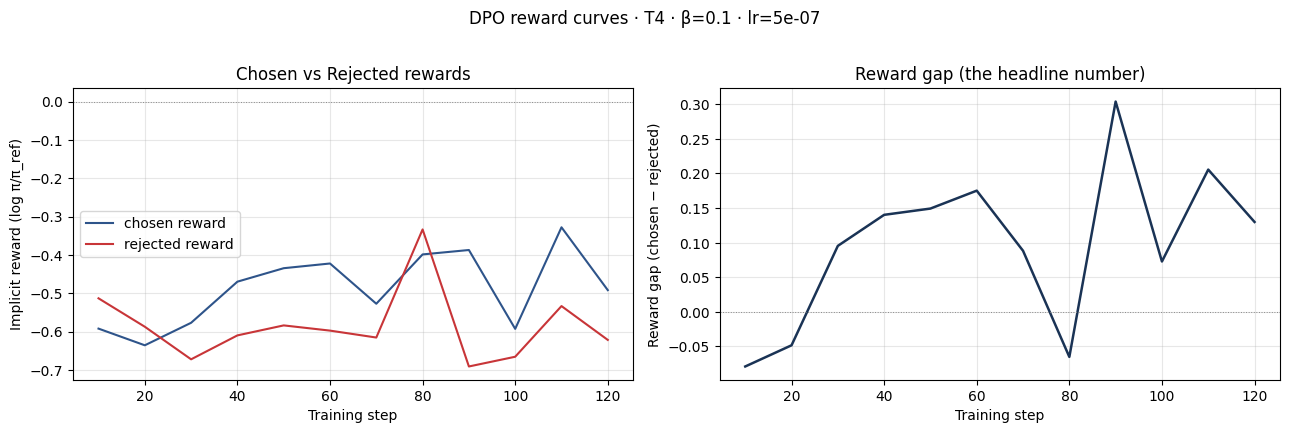

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
logs = logs[logs["loss"].notna() if "loss" in logs.columns else logs.index].copy()

# TRL DPO logs include rewards/chosen, rewards/rejected, rewards/margins, kl
chosen_col = "rewards/chosen" if "rewards/chosen" in logs.columns else None
rejected_col = "rewards/rejected" if "rewards/rejected" in logs.columns else None

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

if chosen_col and rejected_col:
    axes[0].plot(logs["step"], logs[chosen_col], label="chosen reward", color="#2e548a", linewidth=1.5)
    axes[0].plot(logs["step"], logs[rejected_col], label="rejected reward", color="#c83538", linewidth=1.5)
    axes[0].axhline(0, color="#888", linestyle=":", linewidth=0.7)
    axes[0].set_xlabel("Training step")
    axes[0].set_ylabel("Implicit reward (log π/π_ref)")
    axes[0].set_title("Chosen vs Rejected rewards")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    gap = logs[chosen_col] - logs[rejected_col]
    axes[1].plot(logs["step"], gap, color="#1a3355", linewidth=1.8)
    axes[1].axhline(0, color="#888", linestyle=":", linewidth=0.7)
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Reward gap (chosen − rejected)")
    axes[1].set_title("Reward gap (the headline number)")
    axes[1].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "No reward columns in trainer.state.log_history.\nLikely TRL version mismatch.",
                 ha="center", va="center", transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, "—", ha="center", va="center", transform=axes[1].transAxes)

fig.suptitle(f"DPO reward curves · {COMPUTE_TIER} · β={BETA} · lr={LR}", y=1.02)
fig.tight_layout()

screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "03-dpo-reward-curves.png", dpi=120, bbox_inches="tight")
plt.show()

### 5a. Failure-mode self-check

Read this cell carefully — it tells you which kind of "reward gap up" you got.

In [11]:
if chosen_col and rejected_col and len(logs) >= 5:
    last_chosen = logs[chosen_col].iloc[-5:].mean()
    last_rejected = logs[rejected_col].iloc[-5:].mean()
    last_gap = last_chosen - last_rejected
    first_chosen = logs[chosen_col].iloc[:5].mean()

    chosen_delta = last_chosen - first_chosen

    print(f"END  chosen reward:    {last_chosen:+.3f}")
    print(f"END  rejected reward:  {last_rejected:+.3f}")
    print(f"END  reward gap:       {last_gap:+.3f}")
    print()

    if last_gap < 0:
        print("✗ FAILURE: reward gap went NEGATIVE. DPO did the opposite of what you wanted.")
        print("  Likely causes: data quality (chosen/rejected swapped?), beta too high, lr too low.")
    elif chosen_delta < -0.5 and last_gap > 0:
        print("⚠  LIKELIHOOD DISPLACEMENT (deck §3.4):")
        print(f"   Reward gap is positive ({last_gap:+.3f}) — good!")
        print(f"   But chosen reward FELL by {chosen_delta:+.3f} during training.")
        print("   The gap grew because rejected fell faster than chosen.")
        print("   Document this in REFLECTION § 3 — it's a teachable moment, not a bug.")
    elif chosen_delta > 0 and last_gap > 0:
        print("✓ INTENDED: chosen reward UP and gap positive. Classic DPO success.")
    else:
        print("?  AMBIGUOUS: weak chosen movement + positive gap. Try longer training or higher lr.")

END  chosen reward:    -0.440
END  rejected reward:  -0.569
END  reward gap:       +0.129

✓ INTENDED: chosen reward UP and gap positive. Classic DPO success.


## 6. Save adapter

In [12]:
trainer.model.save_pretrained(str(DPO_OUT))
tokenizer.save_pretrained(str(DPO_OUT))
print(f"Saved DPO adapter to {DPO_OUT}")

# Save the headline metrics for verify.py + REFLECTION
import json

metrics = {
    "compute_tier": COMPUTE_TIER,
    "base_model": BASE_MODEL,
    "beta": BETA,
    "lr": LR,
    "epochs": EPOCHS,
    "final_train_loss": float(train_result.training_loss),
    "end_chosen_reward": float(last_chosen) if chosen_col else None,
    "end_rejected_reward": float(last_rejected) if rejected_col else None,
    "end_reward_gap": float(last_gap) if chosen_col and rejected_col else None,
}
(DPO_OUT / "dpo_metrics.json").write_text(json.dumps(metrics, indent=2))
print(f"Wrote metrics to {DPO_OUT / 'dpo_metrics.json'}")

Unsloth: Restored added_tokens_decoder metadata in /content/adapters/dpo/tokenizer_config.json.


Saved DPO adapter to /content/adapters/dpo
Wrote metrics to /content/adapters/dpo/dpo_metrics.json


In [15]:
import shutil
from google.colab import files

# Define the directory to zip
directory_to_zip = "adapters/dpo"
output_filename = "dpo_adapters"

# Create a zip archive of the directory
shutil.make_archive(output_filename, 'zip', directory_to_zip)

# Download the zip file
files.download(f"{output_filename}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Vibe-coding callout

Now's the time for the **β experiment** if you want the +6 rigor add-on.

`make beta-sweep` runs this notebook 3 times with `DPO_BETA ∈ {0.05, 0.1, 0.5}`
and saves to `adapters/dpo-b{0.05,0.1,0.5}/`. Plot the results yourself:

```python
import json
import matplotlib.pyplot as plt
from pathlib import Path

results = []
for d in sorted((REPO_ROOT / "adapters").glob("dpo-b*")):
    m = json.loads((d / "dpo_metrics.json").read_text())
    results.append((m["beta"], m["end_reward_gap"]))
# plot β vs reward_gap
```

**Think-hard zone:** what's the *expected* shape of the β-vs-reward-gap curve?
Hypothesize before you look at the data. (Hint: deck §3.3.)

**Next:** NB4 — qualitative side-by-side comparison.

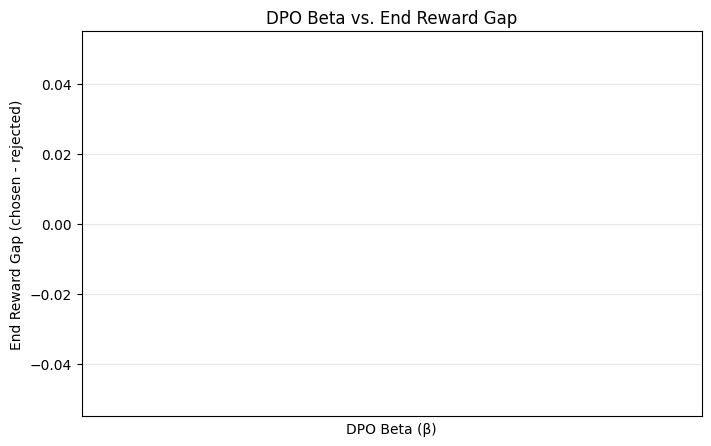

In [13]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

results = []
# Assuming REPO_ROOT is defined in a previous cell
for d in sorted((REPO_ROOT / "adapters").glob("dpo-b*")):
    # Ensure the path exists and contains the metrics file
    metrics_file = d / "dpo_metrics.json"
    if metrics_file.exists():
        m = json.loads(metrics_file.read_text())
        results.append((m["beta"], m["end_reward_gap"]))

# Extract beta values and reward gaps for plotting
betas = [res[0] for res in results]
reward_gaps = [res[1] for res in results]

# Plot β vs reward_gap
plt.figure(figsize=(8, 5))
plt.plot(betas, reward_gaps, marker='o', linestyle='-', color='#1a3355')
plt.xlabel("DPO Beta (β)")
plt.ylabel("End Reward Gap (chosen - rejected)")
plt.title("DPO Beta vs. End Reward Gap")
plt.grid(True, alpha=0.3)
plt.xticks(betas) # Show specific beta values on x-axis
plt.show()